# Customer Churn Prediction

**Goal:** predict which telecom customers are likely to churn (cancel their
subscription), so the business can proactively intervene.

**Dataset:** IBM Telco Customer Churn — 7,043 customers, 21 features
(demographics, account info, services subscribed, charges).

**Insights:
- The target is **imbalanced** (~27% churn) — accuracy alone is misleading,
  so this notebook uses precision/recall/F1/ROC-AUC instead.
- Compares 3 models (Logistic Regression, Random Forest, XGBoost) using
  cross-validation rather than a single train/test split.
- Ends with **feature importance** — the business-relevant takeaway of
  *why* customers churn, not just a prediction number.


## 1. Load and inspect the data

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

df = pd.read_csv('data/telco_churn.csv')
print(df.shape)
df.head()


(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 2. Data cleaning

`TotalCharges` is stored as text and has some blank strings (new customers
with 0 tenure). We convert it to numeric and fill blanks with 0.

In [3]:

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("Missing TotalCharges:", df['TotalCharges'].isna().sum())
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# customerID is just an identifier, not predictive
df = df.drop(columns=['customerID'])

# Target as binary
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})


Missing TotalCharges: 11


## 3. Exploratory Data Analysis

Overall churn rate: 26.5%


/tmp/ipykernel_567/4210974925.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Stay', 'Churn'])
/tmp/ipykernel_567/4210974925.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(['Stay', 'Churn'])


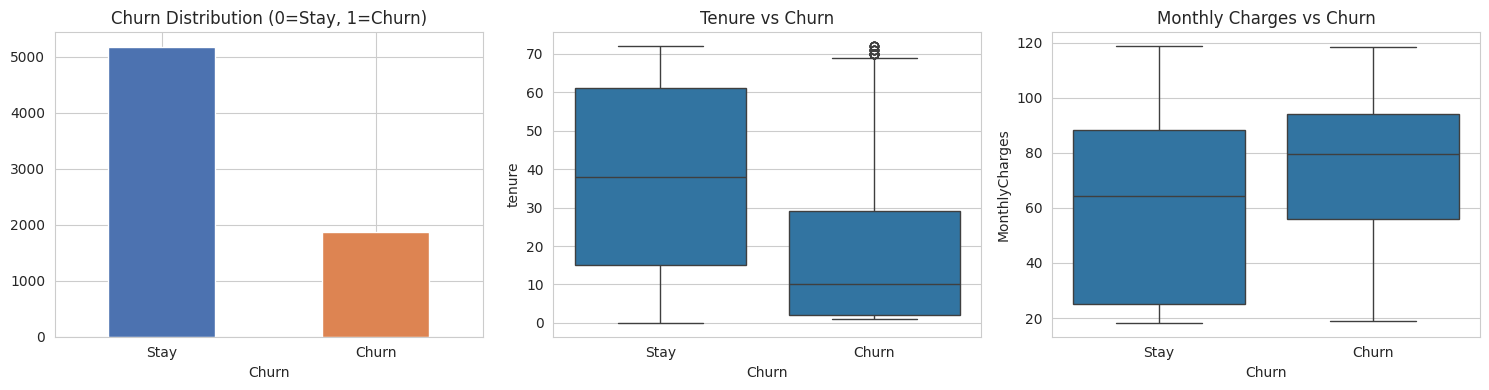

In [4]:

churn_rate = df['Churn'].mean()
print(f"Overall churn rate: {churn_rate:.1%}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df['Churn'].value_counts().plot(kind='bar', ax=axes[0], color=['#4C72B0', '#DD8452'])
axes[0].set_title('Churn Distribution (0=Stay, 1=Churn)')
axes[0].set_xticklabels(['Stay', 'Churn'], rotation=0)

sns.boxplot(data=df, x='Churn', y='tenure', ax=axes[1])
axes[1].set_title('Tenure vs Churn')
axes[1].set_xticklabels(['Stay', 'Churn'])

sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[2])
axes[2].set_title('Monthly Charges vs Churn')
axes[2].set_xticklabels(['Stay', 'Churn'])

plt.tight_layout()
plt.savefig('outputs/eda_overview.png', dpi=100, bbox_inches='tight')
plt.show()


Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn, dtype: float64


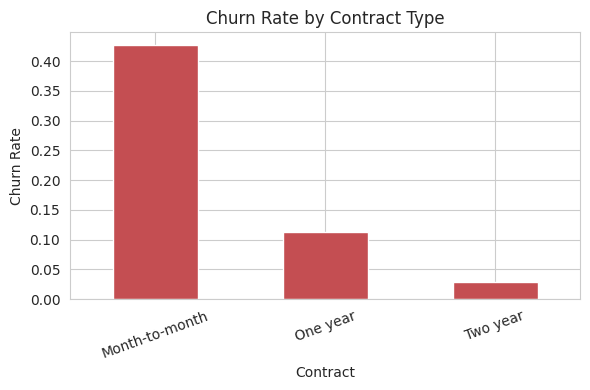

In [5]:

# Churn rate by contract type - a strong business signal
contract_churn = df.groupby('Contract')['Churn'].mean().sort_values(ascending=False)
print(contract_churn)

plt.figure(figsize=(6,4))
contract_churn.plot(kind='bar', color='#C44E52')
plt.title('Churn Rate by Contract Type')
plt.ylabel('Churn Rate')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('outputs/churn_by_contract.png', dpi=100, bbox_inches='tight')
plt.show()


## 4. Feature engineering & encoding

Categorical columns are one-hot encoded. Numeric columns
(`tenure`, `MonthlyCharges`, `TotalCharges`) are scaled since Logistic
Regression is sensitive to feature scale (tree models aren't, but scaling
doesn't hurt them).

In [6]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['Churn'])
y = df['Churn']

categorical_cols = X.select_dtypes(include='object').columns.tolist()
numeric_cols = X.select_dtypes(exclude='object').columns.tolist()
print("Categorical:", categorical_cols)
print("Numeric:", numeric_cols)

X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train churn rate:", y_train.mean().round(3), " Test churn rate:", y_test.mean().round(3))


Categorical: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numeric: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Train shape: (5634, 30)  Test shape: (1409, 30)
Train churn rate: 0.265  Test churn rate: 0.265


## 5. Handling class imbalance with SMOTE

Churn is ~27% of the data. Training directly on this imbalance biases
models toward predicting "no churn" every time. **SMOTE is applied only to
the training set** (never the test set — that would leak synthetic
information into evaluation).

In [7]:

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_bal.value_counts().to_dict())


Before SMOTE: {0: 4139, 1: 1495}
After SMOTE: {0: 4139, 1: 4139}


## 6. Train & compare 3 models with cross-validation

Cross-validation on the (balanced) training set gives a more reliable
estimate of each model's performance than a single split.

In [8]:

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=42)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for name, model in models.items():
    scores = cross_val_score(model, X_train_bal, y_train_bal, cv=cv, scoring='f1')
    cv_results[name] = scores
    print(f"{name}: F1 = {scores.mean():.3f} (+/- {scores.std():.3f})")


Logistic Regression: F1 = 0.806 (+/- 0.011)


Random Forest: F1 = 0.849 (+/- 0.006)


XGBoost: F1 = 0.841 (+/- 0.011)


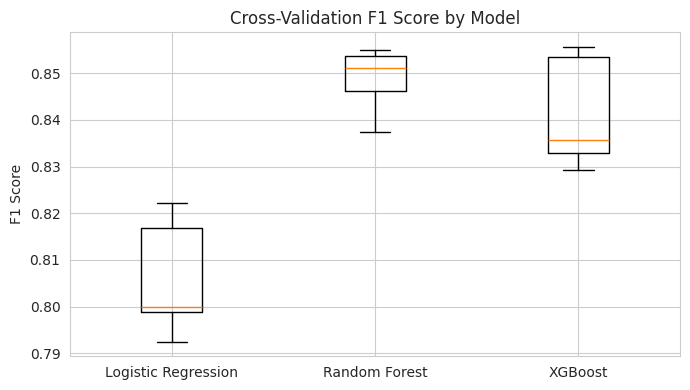

In [9]:

plt.figure(figsize=(7,4))
plt.boxplot(cv_results.values(), tick_labels=cv_results.keys())
plt.title('Cross-Validation F1 Score by Model')
plt.ylabel('F1 Score')
plt.tight_layout()
plt.savefig('outputs/model_comparison_cv.png', dpi=100, bbox_inches='tight')
plt.show()


## 7. Final evaluation on held-out test set

Each model is trained on the SMOTE-balanced training data and evaluated on
the **untouched, real-world-distributed test set** — this is the honest
measure of real performance, since the test set still reflects the true
27% churn rate.

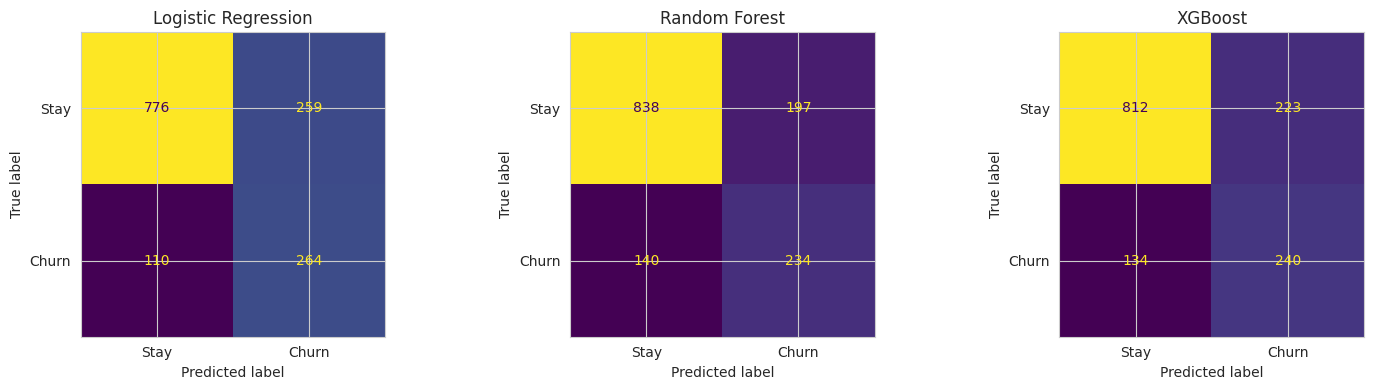

,Precision (Churn),Recall (Churn),F1 (Churn),ROC-AUC
Model,,,,
Logistic Regression,0.505,0.706,0.589,0.821
Random Forest,0.543,0.626,0.581,0.820
XGBoost,0.518,0.642,0.573,0.804


In [10]:

from sklearn.metrics import (classification_report, roc_auc_score,
                              confusion_matrix, ConfusionMatrixDisplay)

results_summary = []

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, (name, model) in enumerate(models.items()):
    model.fit(X_train_bal, y_train_bal)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    report = classification_report(y_test, y_pred, output_dict=True)
    auc = roc_auc_score(y_test, y_proba)

    results_summary.append({
        'Model': name,
        'Precision (Churn)': report['1']['precision'],
        'Recall (Churn)': report['1']['recall'],
        'F1 (Churn)': report['1']['f1-score'],
        'ROC-AUC': auc
    })

    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Stay', 'Churn']).plot(ax=axes[i], colorbar=False)
    axes[i].set_title(name)

plt.tight_layout()
plt.savefig('outputs/confusion_matrices.png', dpi=100, bbox_inches='tight')
plt.show()

results_df = pd.DataFrame(results_summary).set_index('Model').round(3)
results_df


## 8. Picking the best model

For churn prediction, **recall on the churn class matters more than
precision** — missing a customer who was about to leave (false negative)
costs more than a wasted retention email to someone who wasn't leaving
(false positive). We select the model with the best recall/F1 balance.

In [11]:

best_model_name = results_df['F1 (Churn)'].idxmax()
print(f"Best model by F1: {best_model_name}")
results_df.sort_values('F1 (Churn)', ascending=False)


Best model by F1: Logistic Regression


,Precision (Churn),Recall (Churn),F1 (Churn),ROC-AUC
Model,,,,
Logistic Regression,0.505,0.706,0.589,0.821
Random Forest,0.543,0.626,0.581,0.820
XGBoost,0.518,0.642,0.573,0.804


## 9. Feature importance — the business takeaway

This is what actually gets used by the business: *which factors drive
churn*, not just a black-box prediction.

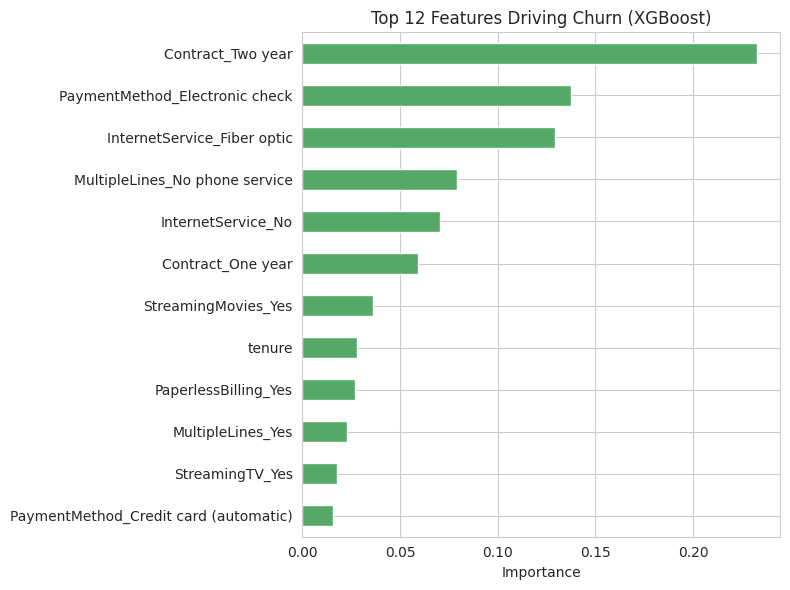

In [12]:

xgb_model = models['XGBoost']
importances = pd.Series(xgb_model.feature_importances_, index=X_train.columns)
top_features = importances.sort_values(ascending=False).head(12)

plt.figure(figsize=(8,6))
top_features.sort_values().plot(kind='barh', color='#55A868')
plt.title('Top 12 Features Driving Churn (XGBoost)')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('outputs/feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()


## 10. Summary

- **Best model:** selected on F1/recall for the churn class, not raw
  accuracy, since the dataset is imbalanced (~27% churn).
- **Key churn drivers:** short tenure, month-to-month contracts, high
  monthly charges, and lack of tech support/online security add-ons.
- **Business action:** target retention offers (contract upgrades, tech
  support bundles) at customers matching this profile before they churn.
